# 📉 The Architect’s Guide to Loss Functions  
### From Feedback Loops to Model Optimization

---

## 🎯 1. Introduction: Loss as the Model’s “Eye”

In deep learning, a **loss function** is not just a formula — it is the **feedback mechanism** that guides learning.

- It measures the difference between **prediction (ŷ)** and **actual value (y)**
- Converts error into **gradients**
- Guides **weight updates via Gradient Descent**

👉 Think of it as the model’s **“eye”**:
- Large error → large update  
- Small error → fine adjustment  

⚠️ If the loss function is poorly chosen:
- Model may not converge  
- May get stuck in local minima  
- Learning becomes ineffective  

---

## ⚙️ 2. Loss Function vs Cost Function

### 🔹 Loss Function
- Error for **one data point**
- Example:
  - Predicted salary = 6.1L  
  - Actual salary = 6.3L  
  - Loss = error for this instance  

---

### 🔹 Cost Function
- **Average loss over dataset or batch**

\[
\text{Cost} = \frac{1}{n} \sum_{i=1}^{n} \text{Loss}(y_i, \hat{y}_i)
\]

👉 Why important?
- Provides **stable gradients**
- Controls **global learning behavior**

---

## 📊 3. Regression Loss Functions

Used when output is **continuous (numbers)**

---

### 🔸 Mean Squared Error (MSE)

\[
MSE = \frac{1}{n} \sum (y - \hat{y})^2
\]

**Key Idea:**
- Penalizes large errors heavily (squared)

**Pros:**
- Smooth & differentiable  
- Fast convergence  

**Cons:**
- Sensitive to outliers  
- Outliers dominate training  

---

### 🔸 Mean Absolute Error (MAE)

\[
MAE = \frac{1}{n} \sum |y - \hat{y}|
\]

**Key Idea:**
- Linear penalty → robust to outliers  

**Pros:**
- Handles noisy data well  

**Cons:**
- Not differentiable at zero  
- Slower convergence  

---

### 🔸 Huber Loss (Hybrid)

Combines **MSE + MAE**

- Small errors → behaves like MSE  
- Large errors → behaves like MAE  

**Controlled by:** δ (delta)

**Pros:**
- Stable + robust  
- Best for real-world noisy data  

---

### 📌 Comparison

| Feature | MSE | MAE | Huber |
|--------|-----|-----|-------|
| Penalty | Quadratic | Linear | Hybrid |
| Outliers | High impact | Low impact | Balanced |
| Differentiability | Smooth | Not at 0 | Smooth |
| Convergence | Fast | Slower | Balanced |

---

## 🧠 4. Classification Loss Functions

Used when output is **categories / probabilities**

---

### 🔸 Binary Cross-Entropy (BCE)

Used for **binary classification**

- Output layer → **Sigmoid**

\[
Loss = -[y \log(p) + (1-y)\log(1-p)]
\]

---

### 🔸 Categorical Cross-Entropy (CCE)

Used for **multi-class classification**

- Output layer → **Softmax**
- Requires **One-Hot Encoding**

---

### 🔸 Sparse Categorical Cross-Entropy (SCCE)

- Same as CCE  
- Uses **integer labels (no one-hot)**  

**Why useful?**
- Saves memory  
- Faster for large datasets  

---

## 🧭 5. How to Choose Loss Function

### ✅ Decision Guide

| Scenario | Use |
|----------|-----|
| Clean regression data | MSE |
| Noisy data / outliers | MAE |
| Mixed data | Huber |
| Binary classification | BCE |
| Multi-class (small) | CCE |
| Multi-class (large) | SCCE |

---

## ⚠️ 6. Activation + Loss Pairing (CRITICAL)

Wrong pairing = model won’t learn ❌

| Task | Output Layer | Loss |
|------|-------------|------|
| Regression | Linear | MSE / MAE / Huber |
| Binary | Sigmoid | BCE |
| Multi-class | Softmax | CCE / SCCE |

---

## 🎯 7. Key Takeaways

- Loss function = **guiding signal for learning**
- Choice of loss = **critical design decision**
- MSE → fast but sensitive  
- MAE → robust but slower  
- Huber → best trade-off  
- Always match:
  👉 **Loss + Activation + Problem Type**

---

## 🚀 Conclusion

A good model is not just about architecture —  
it’s about **how you measure error**.

> “You can’t improve what you don’t measure correctly.”

Choose your loss function wisely — it defines how your model learns.

## Loss Function Overview

![Loss Function Guide](lossfunction-overview.png)

## 🧪 Experiment: Comparing Loss Functions (MSE vs MAE vs Huber)

Objective:
To analyze how different loss functions behave during training and how they handle errors.

## 🧩 STEP 1: Create Dataset (with outliers)

In [72]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd


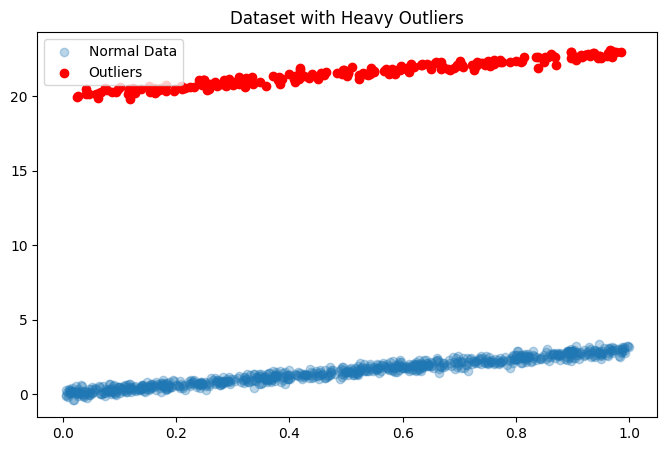

In [73]:
## Generating data set 
np.random.seed(42) ##Fixes the randomness
X = np.random.rand(1000,1) ##Generates 1000 random numbers between 0 and 1
y = 3 * X.squeeze() + np.random.randn(1000) * 0.2 ## y = 3X + noise

# Add outliers(“I randomly selected 20% of data points and  
# injected large noise to simulate real-world anomalies.”
# and evaluate robustness of different loss functions)
# 🔥 Strong outliers (20% data corrupted)
outlier_idx = np.random.choice(np.arange(1000), size=200, replace=False)
y[outlier_idx] += 20

##visualize

plt.figure(figsize=(8,5))

# Normal points
normal_idx = np.setdiff1d(np.arange(len(y)), outlier_idx)
plt.scatter(X[normal_idx], y[normal_idx], alpha=0.3, label="Normal Data")

# Outliers
plt.scatter(X[outlier_idx], y[outlier_idx], color='red', label="Outliers")

plt.title("Dataset with Heavy Outliers")
plt.legend()
plt.show()

## 🧩 STEP 2: Model Function

In [74]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_model(loss_fn):
    model = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(1,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss=loss_fn,
        metrics=['mae']
    )
    return model






In [75]:
## Storing Model Separately
model_mse = build_model('mse')
model_mae = build_model('mae')
model_huber = build_model(keras.losses.Huber())


## 🧩 STEP 3: Train Models

In [76]:
model_mse.fit(X, y, epochs=30, verbose=0)
model_mae.fit(X, y, epochs=30, verbose=0)
model_huber.fit(X, y, epochs=30, verbose=0)

## 🧩 STEP 4: Predicting the output

In [77]:
x_test = np.linspace(0, 1, 100)

y_mse = model_mse.predict(x_test)
y_mae = model_mae.predict(x_test)
y_huber = model_huber.predict(x_test)

4/4 [==============================] - 0s 3ms/step


## 🧩 STEP 4: Plot Comparison

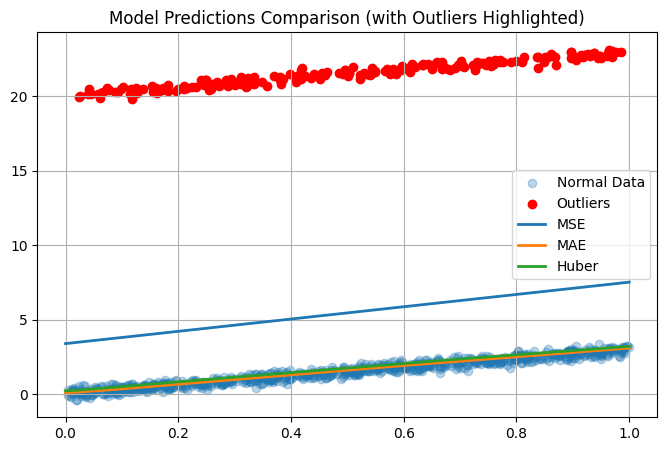

In [81]:
plt.figure(figsize=(8,5))

# Normal points
normal_idx = np.setdiff1d(np.arange(len(y)), outlier_idx)
plt.scatter(X[normal_idx], y[normal_idx], alpha=0.3, label="Normal Data")

# Outliers (highlighted)
plt.scatter(X[outlier_idx], y[outlier_idx], color='red', label="Outliers")

# Model predictions
plt.plot(x_test, y_mse, label="MSE", linewidth=2)
plt.plot(x_test, y_mae, label="MAE", linewidth=2)
plt.plot(x_test, y_huber, label="Huber", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Model Predictions Comparison (with Outliers Highlighted)")
plt.show()


## 🧩STEP 5: Predictions Camparison

🔵 MSE
Line is clearly shifted toward outliers
Trying hard to reduce large squared errors

🟠 MAE
Line stays closer to dense (normal) data
Less affected by extreme values

🟢 Huber
Lies between MSE and MAE
Balances sensitivity and robustness



## 🔑 Key Observations: Loss Function Behavior

### 1. Effect of Outliers on Different Loss Functions

- **Mean Squared Error (MSE)**  
  - Amplifies large errors due to squaring.  
  - Regression line shifts toward outliers.  
  - Highly sensitive to extreme values.

- **Mean Absolute Error (MAE)**  
  - Treats all errors linearly.  
  - Remains stable and aligned with the majority of data.  
  - Robust to outliers but may converge slower.

- **Huber Loss**  
  - Combines properties of MSE and MAE.  
  - Behaves like MSE for small errors (smooth learning).  
  - Behaves like MAE for large errors (robust to outliers).  
  - Produces a balanced and stable fit.

---

### 2. Impact of Outlier Distribution

- When outliers were **random and symmetric**, their effect was minimal due to cancellation.
- When outliers were **biased (shifted in one direction)**, the difference between loss functions became clearly visible.
- This highlights that **structure of noise matters more than just magnitude**.

---

### 3. Model Behavior Summary

- **MSE** → Best for clean data, but heavily influenced by outliers  
- **MAE** → Robust to outliers, but less smooth optimization  
- **Huber** → Best trade-off for real-world datasets with moderate noise  

---

### 4. Key Takeaway

> The choice of loss function should be guided by the data distribution.  
> In real-world scenarios with mixed data quality, **Huber Loss provides the most balanced performance** by combining robustness and stability.

## 🌍 Real-world relevance

In power systems:
- Sensor data often contains anomalies
- Choosing wrong loss function can lead to incorrect predictions

This experiment simulates such conditions.